<a href="https://colab.research.google.com/github/rhodes-byu/cs180-winter25/blob/main/labs/04-wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

# BYU CS 180 Lab 4: Data Wrangling

## Introduction:
In this lab, we will analyze college football data from the years 2016-2020. The data is spread across multiple files and will require a bit of “data wrangling”.

Once we have cleaned and processed the data, we will put our statistics knowledge to good use by digging a little deeper than simple summary statistics.

Very rarely are data scientists handed a pristine data set ready for analysis. More often than not, quite a bit of work is required to clean and preprocess the data so that it's ready for analysis.

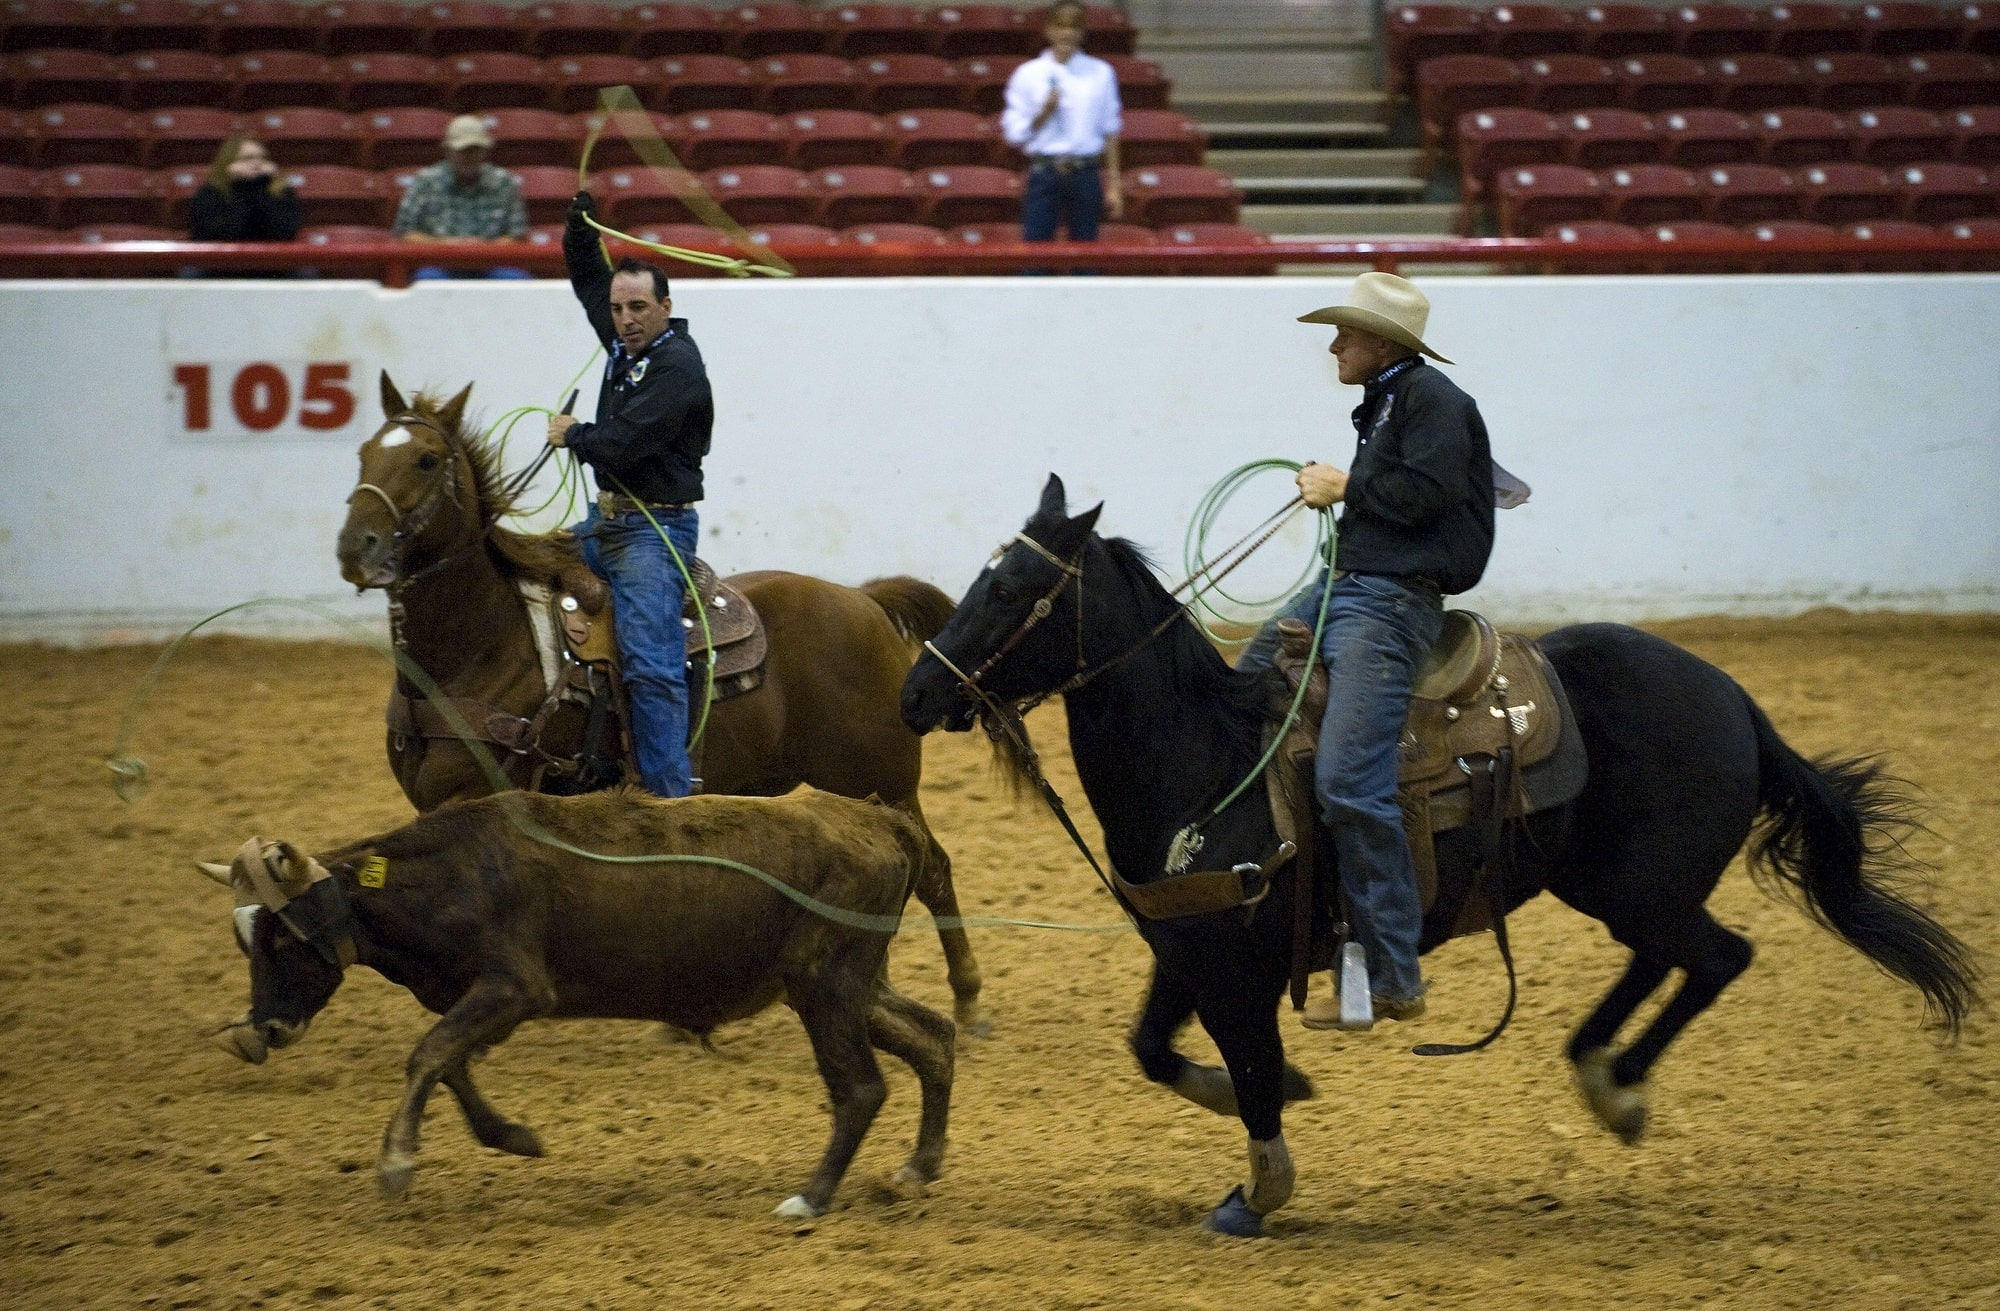

**Data wrangling**, also called **data cleaning**, **data remediation**, or **data munging**, refers to a variety of processes designed to transform raw data into more readily usable formats. The exact methods differ from project to project depending on the data you’re leveraging and the goal you’re trying to achieve.

Some examples of data wrangling include:

- Merging multiple data sources into a single dataset for analysis.

- Identifying gaps in data (for example, empty cells in a spreadsheet) and either filling or deleting them.

- Deleting data that’s either unnecessary or irrelevant to the project you’re working on.

- Identifying extreme outliers in data and either explaining the discrepancies or removing them.

#### Measures of Variability
We are very used to comparing point estimates. For example, in order to tell if one thing is better than the other, we may look at the average of each over time. Consider the following plot comparing the average of two groups, mu_0 and mu_1.

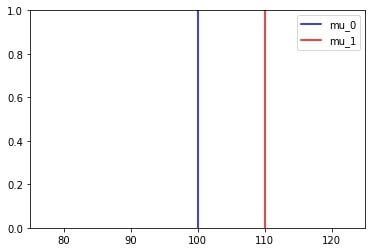

In this case, we might conclude that mu_1 is greater because it’s average is higher. However, we are ignoring an important aspect of the data: its variability.

When we plot the **variability and the mean**, we observe the following plot:

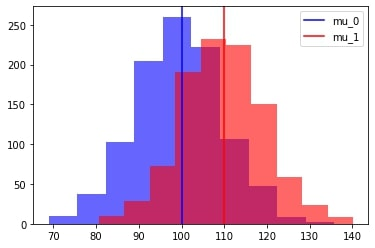

Now the distributions of mu_1 and mu_0 are so close that it’s difficult to say with certainty that mu_1 is better. For any random draw of mu_1, it’s roughly a 50-50 chance to actually be greater than a random draw of mu_0.

Now suppose we observe the following plot:

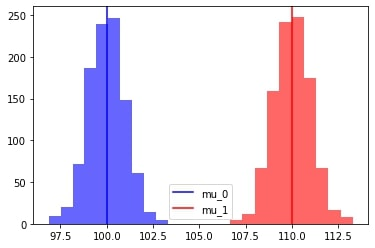

While the means are the same as before, the variability of the two distributions are now very different. We can say with a high degree of certainty that mu_1 is higher.

Keep this idea in mind as you analyze the dataset for this lab.

### **Data:**
Data from the 2016, 2017, 2018, 2019, and 2020 college football seasons are also available on the course GitHub:

In [71]:
# Download the data located at the following URLs
cfb16_url = "https://raw.githubusercontent.com/rhodes-byu/cs180-winter25/refs/heads/main/labs/data/cfb16.csv"
cfb17_url = "https://raw.githubusercontent.com/rhodes-byu/cs180-winter25/refs/heads/main/labs/data/cfb17.csv"
cfb18_url = "https://raw.githubusercontent.com/rhodes-byu/cs180-winter25/refs/heads/main/labs/data/cfb18.csv"
cfb19_url = "https://raw.githubusercontent.com/rhodes-byu/cs180-winter25/refs/heads/main/labs/data/cfb19.csv"
cfb20_url = "https://raw.githubusercontent.com/rhodes-byu/cs180-winter25/refs/heads/main/labs/data/cfb20.csv"

## Exercise 1: Yearly Counts

### Exercise Question
Read in the files, and add a year column to each file (from the original .csv file name).

In [72]:
# Write your code to read in the files and add the year values from each csv:
import pandas as pd

year_16 = pd.read_csv(cfb16_url)
year_16['Year'] = 2016

year_17 = pd.read_csv(cfb17_url)
year_17['Year'] = 2017

year_18 = pd.read_csv(cfb18_url)
year_18['Year'] = 2018

year_19 = pd.read_csv(cfb19_url)
year_19['Year'] = 2019

year_20 = pd.read_csv(cfb20_url)
year_20['Year'] = 2020


## Exercise 2: Data Aggregation

### Exercise Question
Combine every file into a single dataframe.

In [73]:
# Write your code to combine all of the csvs into one dataframe here:

all_data = pd.concat([year_16, year_17, year_18, year_19, year_20])

all_data.head()

,Team,Games,Win,Loss,Off.Rank,Off.Plays,Off.Yards,Off.Yards.Play,Off.TDs,Off.Yards.per.Game,...,Turnover.Rank,Fumbles.Recovered,Opponents.Intercepted,Turnovers.Gain,Fumbles.Lost,Interceptions.Thrown.y,Turnovers.Lost,Turnover.Margin,Avg.Turnover.Margin.per.Game,Year
0,Akron (MAC),12,5,7,84,776,4649,5.99,38,387.4,...,114,6,8,14,8,14,22,-8,-0.67,2016
1,Alabama (SEC),15,14,1,34,1056,6829,6.47,59,455.3,...,17,13,16,29,10,9,19,10,0.67,2016
2,Appalachian St. (Sun Belt),13,10,3,52,912,5589,6.13,45,429.9,...,18,1,20,21,5,8,13,8,0.62,2016
3,Arizona (Pac-12),12,3,9,67,815,4957,6.08,39,413.1,...,112,6,8,14,9,12,21,-7,-0.58,2016
4,Arizona St. (Pac-12),12,5,7,81,900,4689,5.21,43,390.8,...,93,8,9,17,7,14,21,-4,-0.33,2016


## Exercise 3: Conference Search

### Exercise Question
Create a `conference` field by parsing the `team` column.



Example:

| Team | Conference |
| --- | --- |
| Penn State University (Big Ten) | Big Ten |

In [74]:
split_teams = all_data['Team'].str.split("(")
all_data['Team'] = split_teams.str[0]
all_data['Conference'] = split_teams.str[1].str[:-1]

other_col = [col for col in all_data if col != "Team" and col != "Conference"]



all_data.head()

,Team,Games,Win,Loss,Off.Rank,Off.Plays,Off.Yards,Off.Yards.Play,Off.TDs,Off.Yards.per.Game,...,Fumbles.Recovered,Opponents.Intercepted,Turnovers.Gain,Fumbles.Lost,Interceptions.Thrown.y,Turnovers.Lost,Turnover.Margin,Avg.Turnover.Margin.per.Game,Year,Conference
0,Akron,12,5,7,84,776,4649,5.99,38,387.4,...,6,8,14,8,14,22,-8,-0.67,2016,MAC
1,Alabama,15,14,1,34,1056,6829,6.47,59,455.3,...,13,16,29,10,9,19,10,0.67,2016,SEC
2,Appalachian St.,13,10,3,52,912,5589,6.13,45,429.9,...,1,20,21,5,8,13,8,0.62,2016,Sun Belt
3,Arizona,12,3,9,67,815,4957,6.08,39,413.1,...,6,8,14,9,12,21,-7,-0.58,2016,Pac-12
4,Arizona St.,12,5,7,81,900,4689,5.21,43,390.8,...,8,9,17,7,14,21,-4,-0.33,2016,Pac-12


## Exercise 4: Big Ten Vs. South Eastern

### Exercise Question 4a: Offense
- Is there a statistical difference between the Big Ten Conference and the South Eastern Conference in terms of `Off.Yards.per.Game`? Use a [seaborn KDE]("https://seaborn.pydata.org/generated/seaborn.kdeplot.html") plot to create a figure. Comment on the difference in means and the overlap of distributions.

- Do the same as above for `Off.TDs`.

<Axes: xlabel='Off.Yards.per.Game', ylabel='Density'>

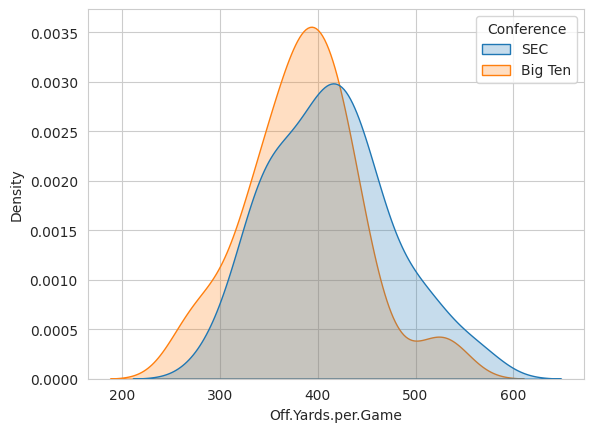

In [64]:
# Write the code for the statistical differences for Off.Yards.per.Game:
import seaborn as sns

filt_data = all_data[all_data['Conference'].isin(['Big Ten', 'SEC'])]

sns.kdeplot(data=filt_data, x='Off.Yards.per.Game', hue='Conference', fill=True)


Means - the SEC has a slightly higher mean in off-yards/game compared to the Big 10, with an average of ~425 yds compared to ~375 yds, respectively.
Overlap - most of the area in both conferences overlaps, suggesting that teams in both conferences perform at similar levels when it comes to off-yards/game. However, the areas that don't overlaps, the SEC has a longer tail to its right, passing the 600 yd mark, while the Big 10 goes the opposite way, towards the 200 yd. mark, suggesting that the SEC has some higher-performing teams compared to the BIG 10 in terms of off-yards per game.

<Axes: xlabel='Off.TDs', ylabel='Density'>

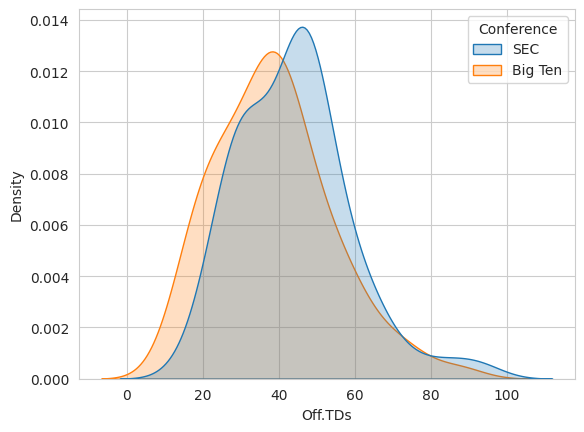

In [65]:
# Write the code for the statistical differences for Off.TDs:
sns.kdeplot(data=filt_data, x='Off.TDs', hue='Conference', fill=True)

Means - Again, the SEC has a slightly higher average than that of the Big 10, with averages of 50 and 35 TDs, respectively.
Overlap - they also overlap greatly, suggesting similar performace between both conferences. However, both teams seem to trail a bit past the 100 TDs mark. However, the Big 10 has a tail the SEC doesn't towards the 0 TDs mark, suggesting that the Big 10 has teams that perform significantly lower than the SEC.

### Exercise Question 4b: Defense
- Is there a statistical difference between the Big Ten Conference and the South Eastern Conference in terms  of `Points.Allowed`? Use a  [seaborn KDE]("https://seaborn.pydata.org/generated/seaborn.kdeplot.html") plot to create a figure.  Comment on the difference in means and the overlap of distributions.

- Do the same as above for `Opp.Pass.Yds.Allowed` and `Opp.Rush.Yards.Allowed`.



<Axes: xlabel='Points.Allowed', ylabel='Density'>

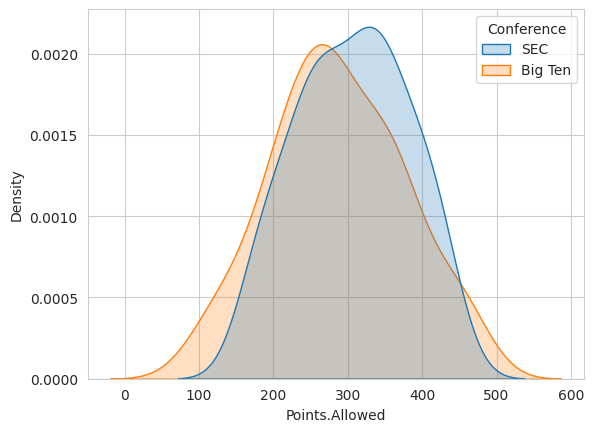

In [66]:
# Write the code for the statistical differences for Points.Allowed:
sns.kdeplot(data=filt_data, x='Points.Allowed', fill=True, hue='Conference')

* Means: the SEC allowed more points than the Big10, with an average of 350 allowed TDs, compared to the Big 10's 250 TDs.   
* Overlap - the overlap between both conferences is great, once again suggesting similar performance among teams in both conference in terms of touchdowns alloed. However, the Big10 trails on both sides of the scale, suggesting that teams were both allowing more TDs than teams in the SEC and also allowing much less TDs, approaching nthe 0 TD mark.


<Axes: xlabel='Opp.Pass.Yds.Allowed', ylabel='Density'>

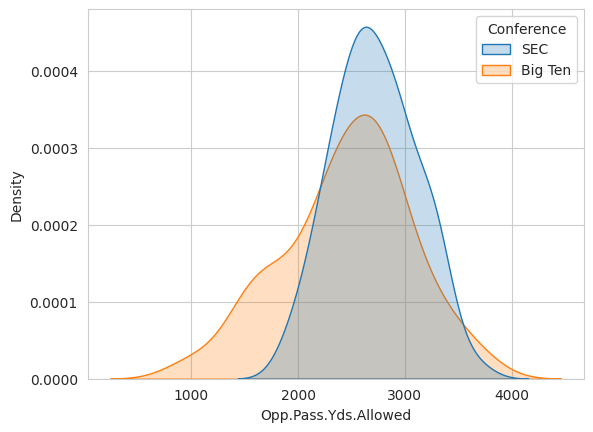

In [67]:
# Write the code for the statistical differences for Opp.Pass.Yds.Allowed:
sns.kdeplot(data=filt_data, x='Opp.Pass.Yds.Allowed', hue='Conference', fill=True)



*   Means: Both the BIG10 and SEC have around the same mean opp pass yds allowed.However, one can observe that the density is much higher in the SEC's meaning that SEC were closer to this averge (less standard deviations), compared to that of the Big 10.
*   Overlap: This is related to the point made in the "means" section. It is obserbed that the BIG10 conference has a far greater density on the left tail, passing the 1000 opp.pass.yds.allowed, and a bit as well on the opposite side, passing the 4000 yrds mark. This suggests that the SEC is by far more ***consistent*** than the BIG 10 at allowing a certain number of yards, while the Big 10 isn't as consistent and has a broader range of yards allowed.



<Axes: xlabel='Opp.Rush.Yards.Allowed', ylabel='Density'>

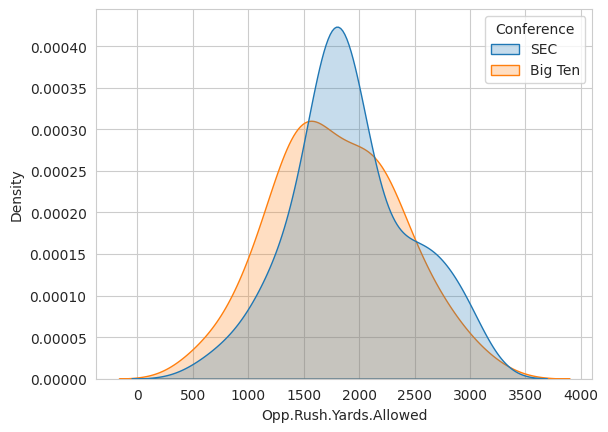

In [68]:
# Write the code for the statistical differences for Opp.Rush.Yards.Allowed:
statistical_table = filt_data.groupby('Conference')['Off.Yards.per.Game'].describe()
statistical_table

sns.kdeplot(data=filt_data, x='Opp.Rush.Yards.Allowed', fill=True, hue='Conference')

[link text](https://)(Comment on the difference in means and the overlap of distributions here)

*   Means: the average for the SEC is a bit higher than that of the Big 10, with ~1750 yds rush yards allowed by the former, and 1400 yds by the latter. Again, the SEC has more teams allowing yards around the team, making it more consistent. This becasue the spike is much higher in the SEC's curve than that of the Big 10.
*   Overlap: teams perform at a similar level, as much of their areas overlap. However, the big10 has more teams allowing less yards, as the density on the left side is greater on the Big10's curve compared to that of the SEC's.



## Exercise 5: Offense Statistics

### Exercise Question 5a: Offense
Is the offense changing over time? Create some plots showing the average offensive production over time (each year). Include an estimate of the variability in your figures.

Comment on whether any trends you see are likely to be true or spurious.

Create a plot for the following metrics:
- `Off.Yards.per.Game`
- `Off.TDs`

<Axes: xlabel='Year'>

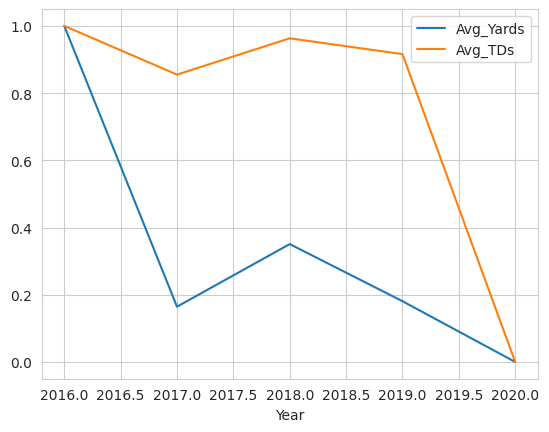

In [69]:
# Create a few plots showing how each metric changed over time:

from sklearn.preprocessing import MinMaxScaler

yearly_stats = all_data.groupby('Year').agg(
    Avg_Yards=('Off.Yards.per.Game', 'mean'),
    Avg_TDs=('Off.TDs', 'mean')
)

scaler = MinMaxScaler()

# Fit the scaler to the data and transform it
# The output is a NumPy array, so we need to put it back into a DataFrame
yearly_stats_normalized = pd.DataFrame(
    scaler.fit_transform(yearly_stats),
    columns=yearly_stats.columns,
    index=yearly_stats.index
)

yearly_stats_normalized.plot()

I had to normalize the data in order to compare it better. But the trent correlates. As avg_yards decrease, so do avg_tds. From 2016 - 2017, boht dereased, with a small increase to 2018, and then a decrease to the lowest it's ever been in 2018.

### Exercise Question 5b: Defense
Is the defense changing over time? Create some plots showing the average defensive production over time (each year). Include an estimate of the variability in your figures.

Comment on whether any trends you see are likely to be true or spurious.

Create a plot for the following metrics:
- `Points.Allowed`
- `Opp.Pass.Yds.Allowed`
- `Opp.Rush.Yards.Allowed`

<Axes: xlabel='Year'>

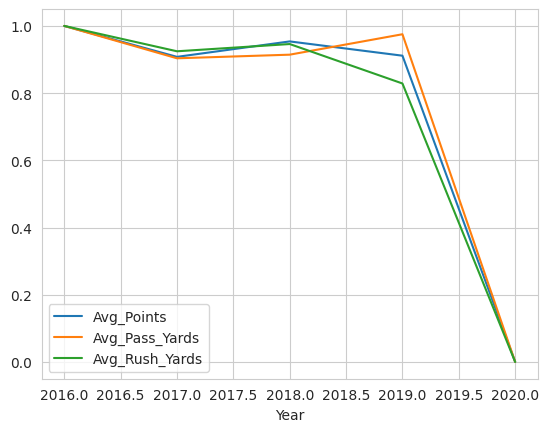

In [70]:
# Create a few plots showing how each metric changed over time:

from sklearn.preprocessing import MinMaxScaler

yearly_stats = all_data.groupby('Year').agg(
    Avg_Points=('Points.Allowed', 'mean'),
    Avg_Pass_Yards=('Opp.Pass.Yds.Allowed', 'mean'),
    Avg_Rush_Yards=('Opp.Rush.Yards.Allowed', 'mean')
)

scaler = MinMaxScaler()

# Fit the scaler to the data and transform it
# The output is a NumPy array, so we need to put it back into a DataFrame
yearly_stats_normalized = pd.DataFrame(
    scaler.fit_transform(yearly_stats),
    columns=yearly_stats.columns,
    index=yearly_stats.index
)

yearly_stats_normalized.plot()

Same thing, as passing and rushing yards, increase, so do othe points, as the increase in yards leads the team closer to the end-zone, producing TDs, or field goals.
The number of pass/rush yard led teams to have a higher avg points from 2016 to 2019, but in 2020 it all decreased.